In [3]:
import requests
import pandas as pd

# 1. Request the data (using IBM's static backup dataset - more reliable than live API)
spacex_url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DS0321EN-SkillsNetwork/datasets/API_call_spacex_api.json"
response = requests.get(spacex_url)
print("Status code:", response.status_code)  # should print 200

# 2. Parse the JSON response into a flat dataframe
data = pd.json_normalize(response.json())

# 3. Quick sanity checks - always look at your data before moving on
print("\nShape of raw data:", data.shape)
print("\nColumns:\n", data.columns.tolist())
print("\nFirst few rows:\n", data.head())

# 4. Keep only the columns we actually need for this analysis
data = data[['rocket', 'payloads', 'launchpad', 'cores', 'flight_number', 'date_utc']]

# 5. Remove multi-core (Falcon Heavy) launches and multi-payload launches
data = data[data['cores'].map(len) == 1]
data = data[data['payloads'].map(len) == 1]

# 6. Extract the single values out of the list columns
data['cores'] = data['cores'].map(lambda x: x[0])
data['payloads'] = data['payloads'].map(lambda x: x[0])

# 7. Convert date_utc to just the date (drop the time component)
data['date'] = pd.to_datetime(data['date_utc']).dt.date

# 8. Only keep launches up to a fixed cutoff date, as the course specifies
data = data[data['date'] <= pd.to_datetime('2020-11-13').date()]

print("\nShape after filtering to single-core, single-payload launches:", data.shape)

# 9. Save checkpoint so the next notebook step can pick up from here
data.to_csv('spacex_data_step1_raw.csv', index=False)
print("\nSaved checkpoint: spacex_data_step1_raw.csv")

Status code: 200

Shape of raw data: (107, 42)

Columns:
 ['static_fire_date_utc', 'static_fire_date_unix', 'tbd', 'net', 'window', 'rocket', 'success', 'details', 'crew', 'ships', 'capsules', 'payloads', 'launchpad', 'auto_update', 'failures', 'flight_number', 'name', 'date_utc', 'date_unix', 'date_local', 'date_precision', 'upcoming', 'cores', 'id', 'fairings.reused', 'fairings.recovery_attempt', 'fairings.recovered', 'fairings.ships', 'links.patch.small', 'links.patch.large', 'links.reddit.campaign', 'links.reddit.launch', 'links.reddit.media', 'links.reddit.recovery', 'links.flickr.small', 'links.flickr.original', 'links.presskit', 'links.webcast', 'links.youtube_id', 'links.article', 'links.wikipedia', 'fairings']

First few rows:
        static_fire_date_utc  static_fire_date_unix    tbd    net  window  \
0  2006-03-17T00:00:00.000Z           1.142554e+09  False  False     0.0   
1                      None                    NaN  False  False     0.0   
2                      No

In [5]:
import pandas as pd

# Load IBM's pre-enriched SpaceX dataset (this is the standard output
# of the rocket/launchpad/payload/core lookups you'd normally do live)
url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DS0321EN-SkillsNetwork/datasets/dataset_part_1.csv"
df = pd.read_csv(url)

print("Shape:", df.shape)
print("\nColumns:\n", df.columns.tolist())
print(df.head())

# Save checkpoint for the next step (data wrangling)
df.to_csv('spacex_data_step2_enriched.csv', index=False)
print("\nSaved checkpoint: spacex_data_step2_enriched.csv")

Shape: (90, 17)

Columns:
 ['FlightNumber', 'Date', 'BoosterVersion', 'PayloadMass', 'Orbit', 'LaunchSite', 'Outcome', 'Flights', 'GridFins', 'Reused', 'Legs', 'LandingPad', 'Block', 'ReusedCount', 'Serial', 'Longitude', 'Latitude']
   FlightNumber        Date BoosterVersion  PayloadMass Orbit    LaunchSite  \
0             1  2010-06-04       Falcon 9  6104.959412   LEO  CCAFS SLC 40   
1             2  2012-05-22       Falcon 9   525.000000   LEO  CCAFS SLC 40   
2             3  2013-03-01       Falcon 9   677.000000   ISS  CCAFS SLC 40   
3             4  2013-09-29       Falcon 9   500.000000    PO   VAFB SLC 4E   
4             5  2013-12-03       Falcon 9  3170.000000   GTO  CCAFS SLC 40   

       Outcome  Flights  GridFins  Reused   Legs LandingPad  Block  \
0    None None        1     False   False  False        NaN    1.0   
1    None None        1     False   False  False        NaN    1.0   
2    None None        1     False   False  False        NaN    1.0   
3  False Oce

In [6]:
import pandas as pd
import numpy as np

# 1. Load the checkpoint saved in Step 2
df = pd.read_csv('spacex_data_step2_enriched.csv')
print("Loaded shape:", df.shape)

# 2. Filter to only Falcon 9 launches
data_falcon9 = df[df['BoosterVersion'] == 'Falcon 9']
print("Shape after filtering to Falcon 9 only:", data_falcon9.shape)

# 3. Check for missing values
print("\nMissing values per column:\n", data_falcon9.isnull().sum())

# 4. Replace missing PayloadMass values with the column mean
payload_mean = data_falcon9['PayloadMass'].mean()
data_falcon9['PayloadMass'] = data_falcon9['PayloadMass'].fillna(payload_mean)
print("\nPayloadMass mean used for imputation:", payload_mean)
print("Missing PayloadMass values after imputation:",
      data_falcon9['PayloadMass'].isnull().sum())

# 5. Explore launch site counts
print("\nLaunches per site:\n", data_falcon9['LaunchSite'].value_counts())

# 6. Explore orbit counts
print("\nLaunches per orbit:\n", data_falcon9['Orbit'].value_counts())

# 7. Explore outcome counts (raw, before converting to a binary label)
print("\nRaw outcome counts:\n", data_falcon9['Outcome'].value_counts())

# 8. Create the binary landing Class label
bad_outcomes = {
    'False None', 'None None', 'False Ocean', 'False ASDS',
    'None ASDS', 'False RTLS'
}

landing_class = []
for outcome in data_falcon9['Outcome']:
    if outcome in bad_outcomes:
        landing_class.append(0)
    else:
        landing_class.append(1)

data_falcon9['Class'] = landing_class

print("\nClass value counts (1 = successful landing, 0 = not):\n",
      data_falcon9['Class'].value_counts())

success_rate = data_falcon9['Class'].mean() * 100
print(f"\nOverall landing success rate: {success_rate:.2f}%")

# 9. Save checkpoint for the next step
data_falcon9.to_csv('spacex_data_step3_wrangled.csv', index=False)
print("\nSaved checkpoint: spacex_data_step3_wrangled.csv")

Loaded shape: (90, 17)
Shape after filtering to Falcon 9 only: (90, 17)

Missing values per column:
 FlightNumber       0
Date               0
BoosterVersion     0
PayloadMass        0
Orbit              0
LaunchSite         0
Outcome            0
Flights            0
GridFins           0
Reused             0
Legs               0
LandingPad        26
Block              0
ReusedCount        0
Serial             0
Longitude          0
Latitude           0
dtype: int64

PayloadMass mean used for imputation: 6104.959411764707
Missing PayloadMass values after imputation: 0

Launches per site:
 LaunchSite
CCAFS SLC 40    55
KSC LC 39A      22
VAFB SLC 4E     13
Name: count, dtype: int64

Launches per orbit:
 Orbit
GTO      27
ISS      21
VLEO     14
PO        9
LEO       7
SSO       5
MEO       3
ES-L1     1
HEO       1
SO        1
GEO       1
Name: count, dtype: int64

Raw outcome counts:
 Outcome
True ASDS      41
None None      19
True RTLS      14
False ASDS      6
True Ocean      5
Fals

In [7]:
import sqlite3
import pandas as pd

# 1. Load the checkpoint saved in Step 3
df = pd.read_csv('spacex_data_step3_wrangled.csv')
print("Loaded shape:", df.shape)

# 2. Create a SQLite database and load the dataframe into a table
conn = sqlite3.connect('spacex_capstone.db')
df.to_sql('SPACEXTBL', conn, if_exists='replace', index=False)
print("Loaded data into SQLite table 'SPACEXTBL'")

# 3. Helper to run a query and print the result nicely
def run_query(query, description):
    result = pd.read_sql_query(query, conn)
    print(f"\n--- {description} ---")
    print(result)
    return result

# 4. Unique launch sites
run_query("SELECT DISTINCT LaunchSite FROM SPACEXTBL;", "Unique launch sites")

# 5. First 5 records where launch site begins with 'CCA'
run_query("SELECT * FROM SPACEXTBL WHERE LaunchSite LIKE 'CCA%' LIMIT 5;",
           "First 5 launches from a CCA-prefixed site")

# 6. Total payload mass across all launches
run_query("SELECT SUM(PayloadMass) AS Total_Payload_Mass FROM SPACEXTBL;",
           "Total payload mass across all launches")

# 7. Average payload mass for Falcon 9
run_query("SELECT AVG(PayloadMass) AS Average_Payload_Mass FROM SPACEXTBL "
           "WHERE BoosterVersion = 'Falcon 9';",
           "Average payload mass for Falcon 9")

# 8. Minimum payload mass
run_query("SELECT MIN(PayloadMass) AS Min_Payload_Mass FROM SPACEXTBL;",
           "Minimum payload mass")

# 9. Mission outcome counts per launch site
run_query("SELECT LaunchSite, Outcome, COUNT(*) AS Outcome_Count "
           "FROM SPACEXTBL GROUP BY LaunchSite, Outcome;",
           "Mission outcome counts per launch site")

# 10. Successful vs unsuccessful landings overall
run_query("SELECT Class, COUNT(*) AS Count FROM SPACEXTBL GROUP BY Class;",
           "Successful (1) vs unsuccessful (0) landings")

conn.close()
print("\nSQL EDA complete. Database saved as spacex_capstone.db")

Loaded shape: (90, 18)
Loaded data into SQLite table 'SPACEXTBL'

--- Unique launch sites ---
     LaunchSite
0  CCAFS SLC 40
1   VAFB SLC 4E
2    KSC LC 39A

--- First 5 launches from a CCA-prefixed site ---
   FlightNumber        Date BoosterVersion  PayloadMass Orbit    LaunchSite  \
0             1  2010-06-04       Falcon 9  6104.959412   LEO  CCAFS SLC 40   
1             2  2012-05-22       Falcon 9   525.000000   LEO  CCAFS SLC 40   
2             3  2013-03-01       Falcon 9   677.000000   ISS  CCAFS SLC 40   
3             5  2013-12-03       Falcon 9  3170.000000   GTO  CCAFS SLC 40   
4             6  2014-01-06       Falcon 9  3325.000000   GTO  CCAFS SLC 40   

     Outcome  Flights  GridFins  Reused  Legs LandingPad  Block  ReusedCount  \
0  None None        1         0       0     0       None    1.0            0   
1  None None        1         0       0     0       None    1.0            0   
2  None None        1         0       0     0       None    1.0            0

Loaded shape: (90, 18)


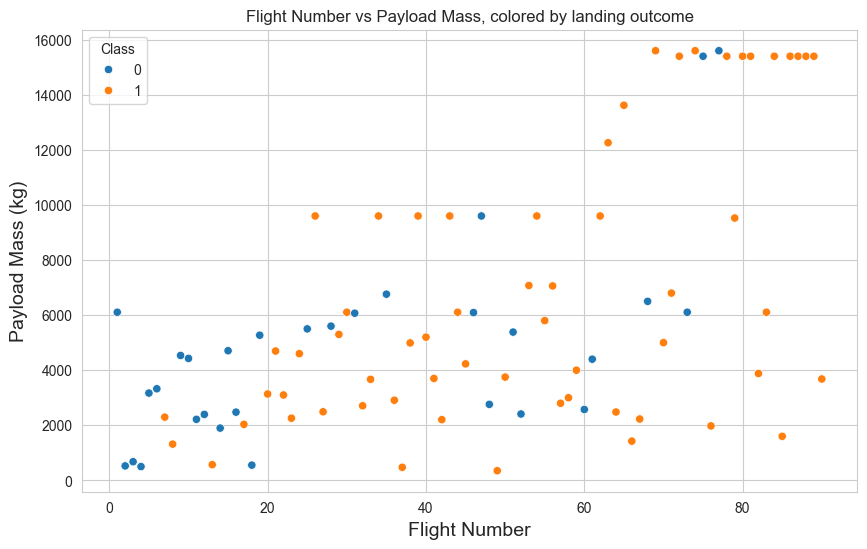

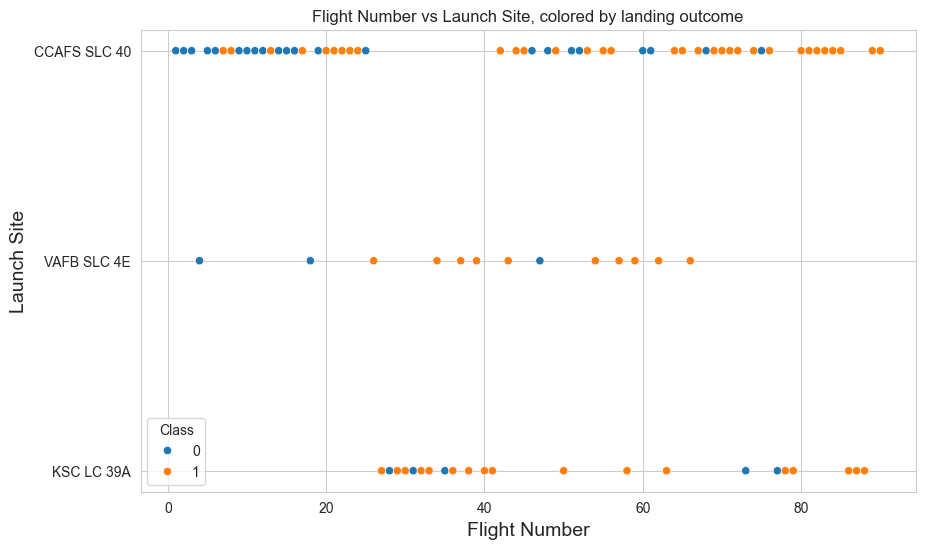

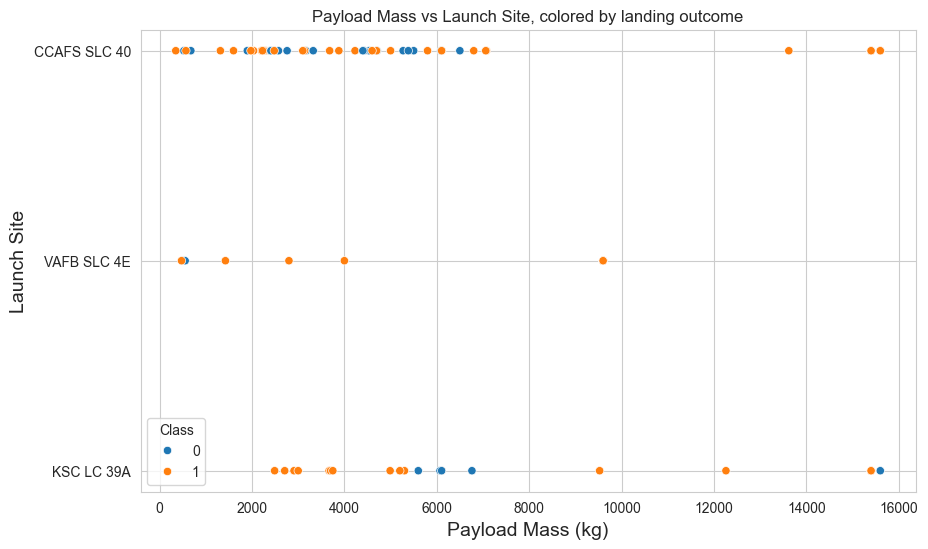

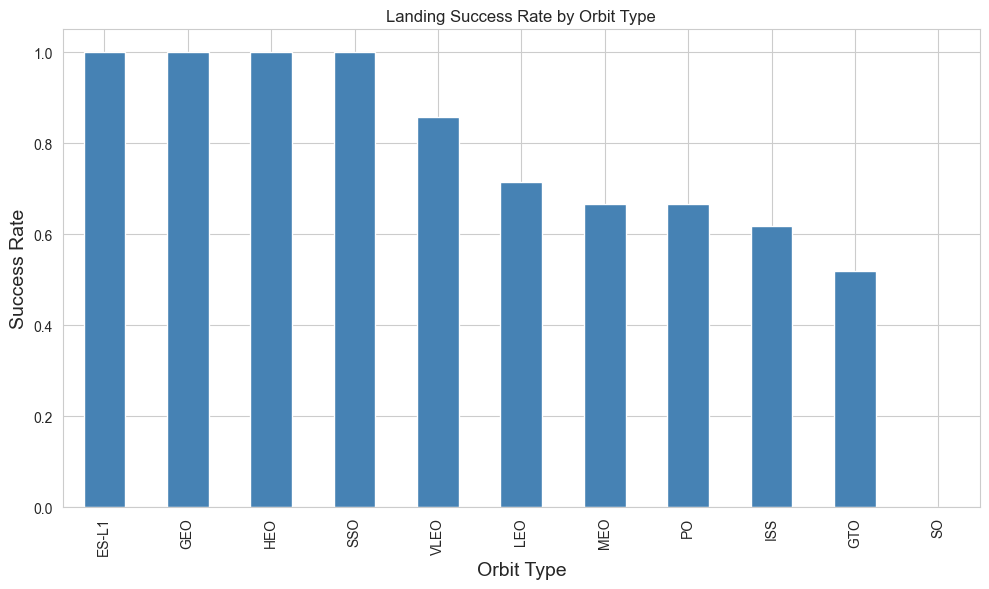

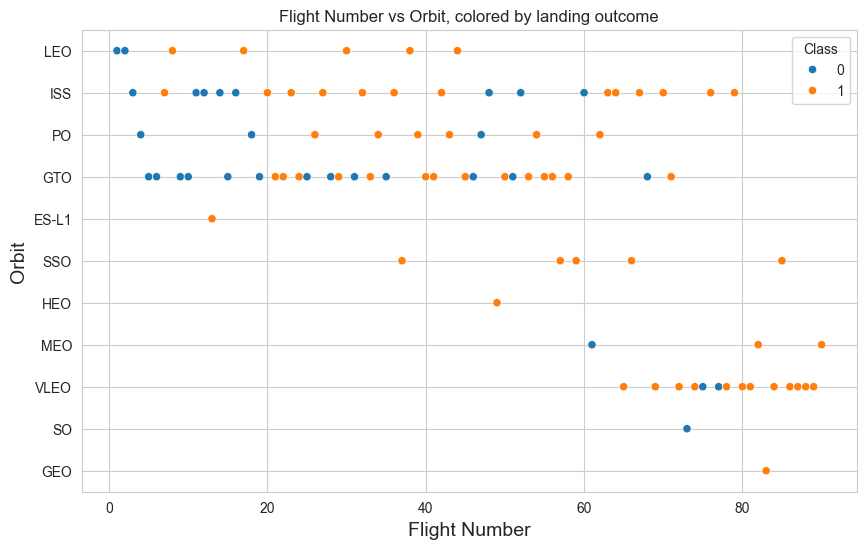

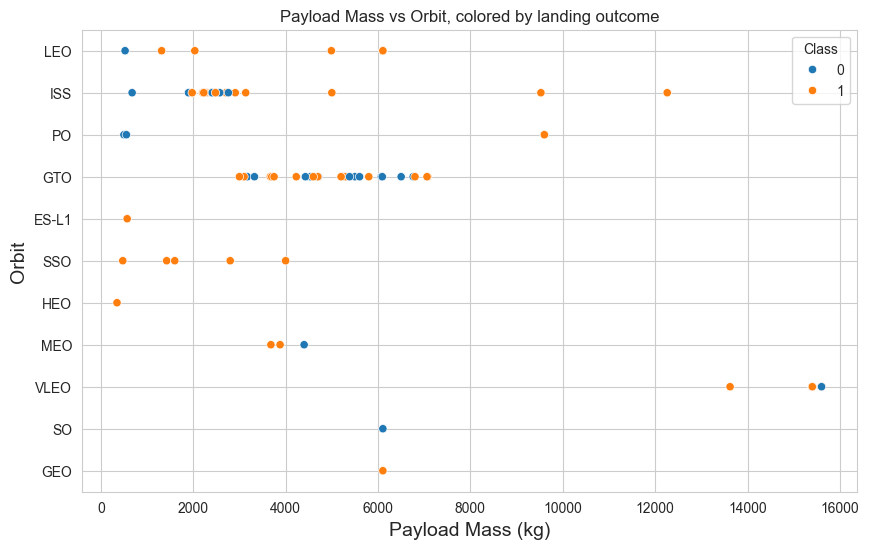

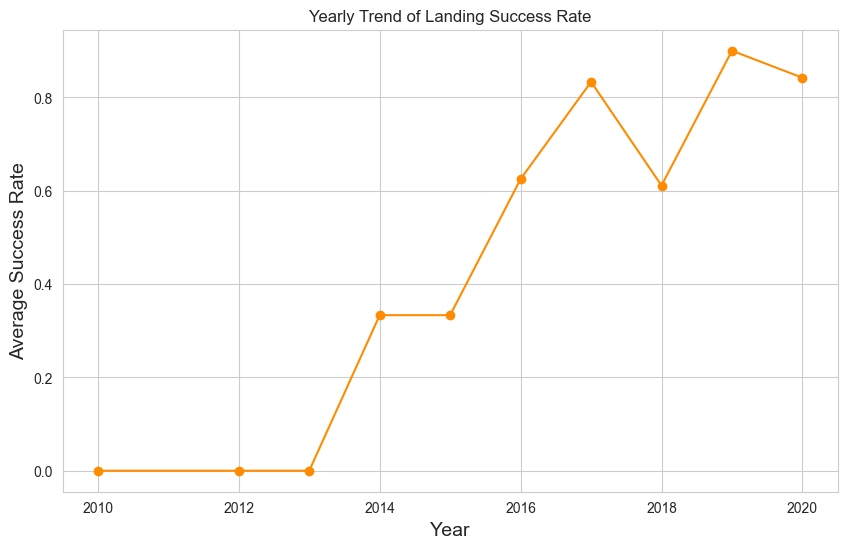


All charts saved as PNG files in the working directory.
Yearly success rate:
 Year
2010    0.000000
2012    0.000000
2013    0.000000
2014    0.333333
2015    0.333333
2016    0.625000
2017    0.833333
2018    0.611111
2019    0.900000
2020    0.842105
Name: Class, dtype: float64


In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load the checkpoint saved in Step 3
df = pd.read_csv('spacex_data_step3_wrangled.csv')
print("Loaded shape:", df.shape)

sns.set_style('whitegrid')

# 2. FlightNumber vs PayloadMass, colored by Class
plt.figure(figsize=(10, 6))
sns.scatterplot(x='FlightNumber', y='PayloadMass', hue='Class', data=df)
plt.xlabel('Flight Number', fontsize=14)
plt.ylabel('Payload Mass (kg)', fontsize=14)
plt.title('Flight Number vs Payload Mass, colored by landing outcome')
plt.savefig('chart1_flightnumber_vs_payloadmass.png', dpi=120, bbox_inches='tight')
plt.show()

# 3. FlightNumber vs LaunchSite, colored by Class
plt.figure(figsize=(10, 6))
sns.scatterplot(x='FlightNumber', y='LaunchSite', hue='Class', data=df)
plt.xlabel('Flight Number', fontsize=14)
plt.ylabel('Launch Site', fontsize=14)
plt.title('Flight Number vs Launch Site, colored by landing outcome')
plt.savefig('chart2_flightnumber_vs_launchsite.png', dpi=120, bbox_inches='tight')
plt.show()

# 4. PayloadMass vs LaunchSite, colored by Class
plt.figure(figsize=(10, 6))
sns.scatterplot(x='PayloadMass', y='LaunchSite', hue='Class', data=df)
plt.xlabel('Payload Mass (kg)', fontsize=14)
plt.ylabel('Launch Site', fontsize=14)
plt.title('Payload Mass vs Launch Site, colored by landing outcome')
plt.savefig('chart3_payloadmass_vs_launchsite.png', dpi=120, bbox_inches='tight')
plt.show()

# 5. Success rate by Orbit type (bar chart)
orbit_success = df.groupby('Orbit')['Class'].mean().sort_values(ascending=False)
plt.figure(figsize=(10, 6))
orbit_success.plot(kind='bar', color='steelblue')
plt.xlabel('Orbit Type', fontsize=14)
plt.ylabel('Success Rate', fontsize=14)
plt.title('Landing Success Rate by Orbit Type')
plt.tight_layout()
plt.savefig('chart4_success_rate_by_orbit.png', dpi=120, bbox_inches='tight')
plt.show()

# 6. FlightNumber vs Orbit, colored by Class
plt.figure(figsize=(10, 6))
sns.scatterplot(x='FlightNumber', y='Orbit', hue='Class', data=df)
plt.xlabel('Flight Number', fontsize=14)
plt.ylabel('Orbit', fontsize=14)
plt.title('Flight Number vs Orbit, colored by landing outcome')
plt.savefig('chart5_flightnumber_vs_orbit.png', dpi=120, bbox_inches='tight')
plt.show()

# 7. PayloadMass vs Orbit, colored by Class
plt.figure(figsize=(10, 6))
sns.scatterplot(x='PayloadMass', y='Orbit', hue='Class', data=df)
plt.xlabel('Payload Mass (kg)', fontsize=14)
plt.ylabel('Orbit', fontsize=14)
plt.title('Payload Mass vs Orbit, colored by landing outcome')
plt.savefig('chart6_payloadmass_vs_orbit.png', dpi=120, bbox_inches='tight')
plt.show()

# 8. Yearly launch success trend
df['Year'] = pd.to_datetime(df['Date']).dt.year
yearly_success = df.groupby('Year')['Class'].mean()

plt.figure(figsize=(10, 6))
yearly_success.plot(kind='line', marker='o', color='darkorange')
plt.xlabel('Year', fontsize=14)
plt.ylabel('Average Success Rate', fontsize=14)
plt.title('Yearly Trend of Landing Success Rate')
plt.grid(True)
plt.savefig('chart7_yearly_success_trend.png', dpi=120, bbox_inches='tight')
plt.show()

print("\nAll charts saved as PNG files in the working directory.")
print("Yearly success rate:\n", yearly_success)

In [11]:
!pip install folium

In [12]:
import pandas as pd
import folium
from folium.plugins import MarkerCluster
from math import sin, cos, sqrt, atan2, radians

# 1. Load the checkpoint saved in Step 3
df = pd.read_csv('spacex_data_step3_wrangled.csv')
print("Loaded shape:", df.shape)

# 2. Build a small dataframe of unique launch sites with their coordinates
launch_sites_df = df.groupby('LaunchSite', as_index=False).agg(
    Latitude=('Latitude', 'first'),
    Longitude=('Longitude', 'first')
)
print("\nUnique launch sites:\n", launch_sites_df)

# 3. Create the base map, centered on the average of all launch site coords
site_map = folium.Map(
    location=[launch_sites_df['Latitude'].mean(), launch_sites_df['Longitude'].mean()],
    zoom_start=4
)

# 4. Mark each launch site with a circle + text label
for _, row in launch_sites_df.iterrows():
    folium.Circle(
        location=[row['Latitude'], row['Longitude']],
        radius=1000,
        color='#000000',
        fill=True
    ).add_child(folium.Popup(row['LaunchSite'])).add_to(site_map)

    folium.map.Marker(
        [row['Latitude'], row['Longitude']],
        icon=folium.DivIcon(
            icon_size=(20, 20),
            icon_anchor=(0, 0),
            html=f'<div style="font-size: 12px; color:#d35400;"><b>{row["LaunchSite"]}</b></div>'
        )
    ).add_to(site_map)

# 5. Add a MarkerCluster with individual launches, colored by outcome
marker_cluster = MarkerCluster().add_to(site_map)

for _, row in df.iterrows():
    marker_color = 'green' if row['Class'] == 1 else 'red'
    folium.Marker(
        location=[row['Latitude'], row['Longitude']],
        icon=folium.Icon(color='white', icon_color=marker_color)
    ).add_to(marker_cluster)

# 6. Save the interactive map to an HTML file
site_map.save('spacex_launch_sites_map.html')
print("\nSaved map: spacex_launch_sites_map.html")

# 7. Distance calculation helper (Haversine formula)
def calculate_distance(lat1, lon1, lat2, lon2):
    R = 6373.0
    lat1, lon1, lat2, lon2 = map(radians, [lat1, lon1, lat2, lon2])
    dlon = lon2 - lon1
    dlat = lat2 - lat1
    a = sin(dlat / 2) ** 2 + cos(lat1) * cos(lat2) * sin(dlon / 2) ** 2
    c = 2 * atan2(sqrt(a), sqrt(1 - a))
    return R * c

# 8. Example: distance from CCAFS SLC 40 to a nearby coastline point
launch_site_lat = launch_sites_df.loc[
    launch_sites_df['LaunchSite'] == 'CCAFS SLC 40', 'Latitude'
].values[0]
launch_site_lon = launch_sites_df.loc[
    launch_sites_df['LaunchSite'] == 'CCAFS SLC 40', 'Longitude'
].values[0]

coastline_lat, coastline_lon = 28.56367, -80.57163

distance_coastline = calculate_distance(
    launch_site_lat, launch_site_lon, coastline_lat, coastline_lon
)
print(f"\nExample distance from CCAFS SLC 40 to nearby coastline: "
      f"{distance_coastline:.2f} km")

print("\nOpen spacex_launch_sites_map.html in your browser to view the map.")

Loaded shape: (90, 18)

Unique launch sites:
      LaunchSite   Latitude   Longitude
0  CCAFS SLC 40  28.561857  -80.577366
1    KSC LC 39A  28.608058  -80.603956
2   VAFB SLC 4E  34.632093 -120.610829

Saved map: spacex_launch_sites_map.html

Example distance from CCAFS SLC 40 to nearby coastline: 0.60 km

Open spacex_launch_sites_map.html in your browser to view the map.


In [14]:
!pip install dash

   ---------------------------------------- 0.0/8.9 MB ? eta -:--:--
   --- ------------------------------------ 0.8/8.9 MB 4.8 MB/s eta 0:00:02
   ---- ----------------------------------- 1.0/8.9 MB 3.9 MB/s eta 0:00:03
   ---- ----------------------------------- 1.0/8.9 MB 3.9 MB/s eta 0:00:03
   ----- ---------------------------------- 1.3/8.9 MB 1.6 MB/s eta 0:00:05
   ------- -------------------------------- 1.6/8.9 MB 1.4 MB/s eta 0:00:06
   ---------- ----------------------------- 2.4/8.9 MB 1.7 MB/s eta 0:00:04
   -------------- ------------------------- 3.1/8.9 MB 2.0 MB/s eta 0:00:03
   ---------------- ----------------------- 3.7/8.9 MB 2.1 MB/s eta 0:00:03
   ------------------- -------------------- 4.5/8.9 MB 2.2 MB/s eta 0:00:03
   ----------------------- ---------------- 5.2/8.9 MB 2.3 MB/s eta 0:00:02
   ------------------------- -------------- 5.8/8.9 MB 2.4 MB/s eta 0:00:02
   ----------------------------- ---------- 6.6/8.9 MB 2.5 MB/s eta 0:00:01
   ----------------

In [15]:
import pandas as pd
import plotly.express as px
from dash import Dash, dcc, html, Input, Output

# 1. Load the wrangled data
spacex_df = pd.read_csv('spacex_data_step3_wrangled.csv')

max_payload = spacex_df['PayloadMass'].max()
min_payload = spacex_df['PayloadMass'].min()

launch_sites = spacex_df['LaunchSite'].unique().tolist()
site_options = [{'label': 'All Sites', 'value': 'ALL'}] + [
    {'label': site, 'value': site} for site in launch_sites
]

# 2. Initialize the Dash app
app = Dash(__name__)

app.layout = html.Div(children=[
    html.H1('SpaceX Falcon 9 Launch Records Dashboard',
            style={'textAlign': 'center', 'color': '#503D36', 'fontSize': 30}),

    dcc.Dropdown(
        id='site-dropdown',
        options=site_options,
        value='ALL',
        placeholder='Select a Launch Site here',
        searchable=True
    ),
    html.Br(),

    html.Div(dcc.Graph(id='success-pie-chart')),
    html.Br(),

    html.P("Payload range (Kg):"),

    dcc.RangeSlider(
        id='payload-slider',
        min=0,
        max=10000,
        step=1000,
        marks={i: str(i) for i in range(0, 10001, 2500)},
        value=[min_payload, max_payload]
    ),

    html.Div(dcc.Graph(id='success-payload-scatter-chart')),
])


@app.callback(
    Output(component_id='success-pie-chart', component_property='figure'),
    Input(component_id='site-dropdown', component_property='value')
)
def get_pie_chart(entered_site):
    if entered_site == 'ALL':
        fig = px.pie(
            spacex_df,
            values='Class',
            names='LaunchSite',
            title='Total Successful Launches by Site'
        )
    else:
        filtered_df = spacex_df[spacex_df['LaunchSite'] == entered_site]
        outcome_counts = filtered_df['Class'].value_counts().reset_index()
        outcome_counts.columns = ['Class', 'count']
        fig = px.pie(
            outcome_counts,
            values='count',
            names='Class',
            title=f'Success vs Failure for site {entered_site}'
        )
    return fig


@app.callback(
    Output(component_id='success-payload-scatter-chart', component_property='figure'),
    [Input(component_id='site-dropdown', component_property='value'),
     Input(component_id='payload-slider', component_property='value')]
)
def get_scatter_chart(entered_site, payload_range):
    low, high = payload_range
    mask = (spacex_df['PayloadMass'] >= low) & (spacex_df['PayloadMass'] <= high)
    filtered_df = spacex_df[mask]

    if entered_site != 'ALL':
        filtered_df = filtered_df[filtered_df['LaunchSite'] == entered_site]

    fig = px.scatter(
        filtered_df,
        x='PayloadMass',
        y='Class',
        color='BoosterVersion',
        title='Payload Mass vs Landing Outcome'
    )
    return fig


if __name__ == '__main__':
    app.run(debug=True)

Loaded shape: (90, 18)

Features shape after one-hot encoding: (90, 80)

Training set size: 72
Test set size: 18

=== Logistic Regression ===
Best params: {'C': 1, 'penalty': 'l2', 'solver': 'lbfgs'}
Validation accuracy: 0.8214
Test accuracy: 0.8333

=== SVM ===
Best params: {'C': 1.0, 'gamma': 0.03162277660168379, 'kernel': 'sigmoid'}
Validation accuracy: 0.8482
Test accuracy: 0.8333

=== Decision Tree ===
Best params: {'criterion': 'gini', 'max_depth': 16, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'splitter': 'best'}
Validation accuracy: 0.8625
Test accuracy: 0.7222

=== KNN ===
Best params: {'algorithm': 'auto', 'n_neighbors': 6, 'p': 1}
Validation accuracy: 0.8339
Test accuracy: 0.8333

=== Model Comparison ===
                     Validation Accuracy  Test Accuracy
Logistic Regression             0.821429       0.833333
SVM                             0.848214       0.833333
KNN                             0.833929       0.833333
Decision Tree         

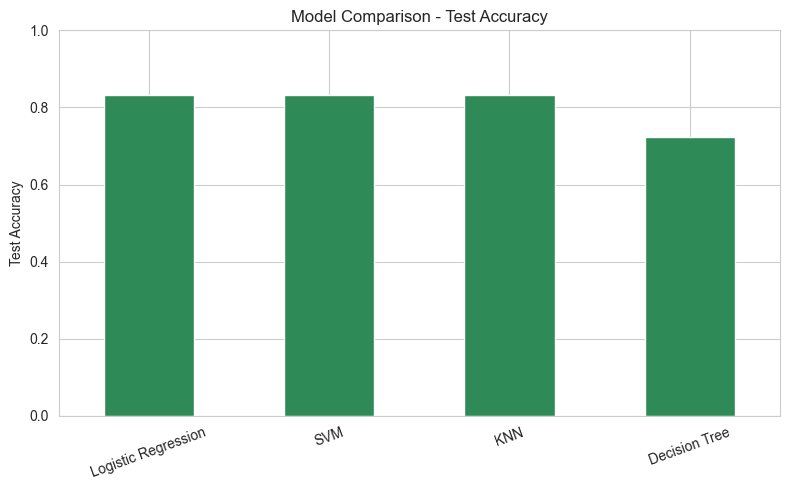

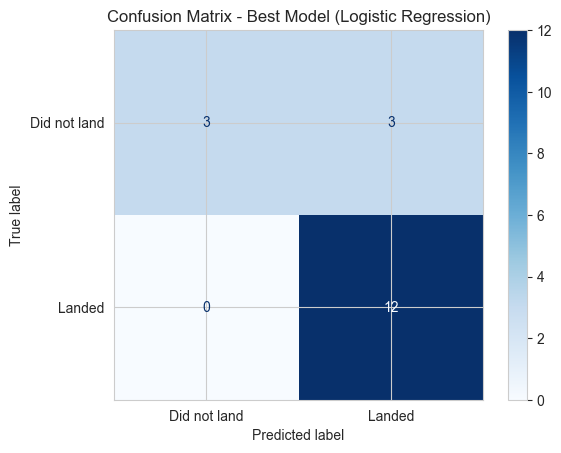


Best model: Logistic Regression
Test accuracy: 0.8333
Best hyperparameters: {'C': 1, 'penalty': 'l2', 'solver': 'lbfgs'}


In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, ConfusionMatrixDisplay

# 1. Load the wrangled data
df = pd.read_csv('spacex_data_step3_wrangled.csv')
print("Loaded shape:", df.shape)

# 2. Build the features dataframe with one-hot encoding on categoricals
features = df[['FlightNumber', 'PayloadMass', 'Orbit', 'LaunchSite', 'Flights',
               'GridFins', 'Reused', 'Legs', 'LandingPad', 'Block',
               'ReusedCount', 'Serial']]

features_one_hot = pd.get_dummies(
    features, columns=['Orbit', 'LaunchSite', 'LandingPad', 'Serial']
)
features_one_hot = features_one_hot.astype('float64')

print("\nFeatures shape after one-hot encoding:", features_one_hot.shape)

# 3. Target variable
Y = df['Class'].to_numpy()

# 4. Standardize the features
X = StandardScaler().fit_transform(features_one_hot)

# 5. Train/test split
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state=2
)
print("\nTraining set size:", X_train.shape[0])
print("Test set size:", X_test.shape[0])

# 6. Define models and hyperparameter grids
models = {
    'Logistic Regression': (
        LogisticRegression(),
        {'C': [0.01, 0.1, 1], 'penalty': ['l2'], 'solver': ['lbfgs']}
    ),
    'SVM': (
        SVC(),
        {'kernel': ('linear', 'rbf', 'poly', 'sigmoid'),
         'C': np.logspace(-3, 3, 5),
         'gamma': np.logspace(-3, 3, 5)}
    ),
    'Decision Tree': (
        DecisionTreeClassifier(),
        {'criterion': ['gini', 'entropy'],
         'splitter': ['best', 'random'],
         'max_depth': [2 * n for n in range(1, 10)],
         'max_features': ['sqrt'],
         'min_samples_leaf': [1, 2, 4],
         'min_samples_split': [2, 5, 10]}
    ),
    'KNN': (
        KNeighborsClassifier(),
        {'n_neighbors': list(range(1, 11)),
         'algorithm': ['auto', 'ball_tree', 'kd_tree', 'brute'],
         'p': [1, 2]}
    ),
}

# 7. Run GridSearchCV for each model
results = {}

for name, (estimator, param_grid) in models.items():
    grid = GridSearchCV(estimator, param_grid, cv=10)
    grid.fit(X_train, Y_train)

    test_accuracy = grid.score(X_test, Y_test)

    results[name] = {
        'best_params': grid.best_params_,
        'validation_accuracy': grid.best_score_,
        'test_accuracy': test_accuracy,
        'best_estimator': grid.best_estimator_
    }

    print(f"\n=== {name} ===")
    print("Best params:", grid.best_params_)
    print(f"Validation accuracy: {grid.best_score_:.4f}")
    print(f"Test accuracy: {test_accuracy:.4f}")

# 8. Compare all models
summary = pd.DataFrame({
    name: {
        'Validation Accuracy': res['validation_accuracy'],
        'Test Accuracy': res['test_accuracy']
    }
    for name, res in results.items()
}).T.sort_values('Test Accuracy', ascending=False)

print("\n=== Model Comparison ===")
print(summary)

# 9. Bar chart comparing test accuracy
plt.figure(figsize=(8, 5))
summary['Test Accuracy'].plot(kind='bar', color='seagreen')
plt.ylabel('Test Accuracy')
plt.title('Model Comparison - Test Accuracy')
plt.ylim(0, 1)
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig('chart8_model_comparison.png', dpi=120, bbox_inches='tight')
plt.show()

# 10. Confusion matrix for the best model
best_model_name = summary.index[0]
best_model = results[best_model_name]['best_estimator']
Y_pred = best_model.predict(X_test)

cm = confusion_matrix(Y_test, Y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Did not land', 'Landed'])
disp.plot(cmap='Blues')
plt.title(f'Confusion Matrix - Best Model ({best_model_name})')
plt.savefig('chart9_confusion_matrix.png', dpi=120, bbox_inches='tight')
plt.show()

print(f"\nBest model: {best_model_name}")
print(f"Test accuracy: {results[best_model_name]['test_accuracy']:.4f}")
print(f"Best hyperparameters: {results[best_model_name]['best_params']}")

In [5]:
import requests
import pandas as pd
import unicodedata
from bs4 import BeautifulSoup

# 1. Request the Wikipedia page (with a browser-like User-Agent, since
# Wikipedia blocks the default python-requests header with a 403)
headers = {
    'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) '
                   'AppleWebKit/537.36 (KHTML, like Gecko) '
                   'Chrome/120.0.0.0 Safari/537.36'
}

static_url = ("https://en.wikipedia.org/w/index.php?title="
              "List_of_Falcon_9_and_Falcon_Heavy_launches&"
              "oldid=1027686922")
response = requests.get(static_url, headers=headers)
print("Status code:", response.status_code)

# 2. Create a BeautifulSoup object from the HTML response
soup = BeautifulSoup(response.text, 'html.parser')
print("\nPage title:", soup.title)

# 3. Find all tables on the page
html_tables = soup.find_all('table')
print(f"\nFound {len(html_tables)} tables on the page.")

for i, table in enumerate(html_tables[:6]):
    caption = table.find('caption')
    print(f"Table {i} caption:", caption.text.strip() if caption else "(no caption)")

# 4. Extract column headers from the target table
first_launch_table = html_tables[2]

column_names = []
for th in first_launch_table.find_all('th'):
    name = th.text.strip()
    if name and not name.isdigit():
        column_names.append(name)

print("\nExtracted column names:\n", column_names)

# 5. Helper functions to clean individual cell values
def date_time(table_cells):
    return [data_time.strip() for data_time in list(table_cells.strings)][0:2]

def booster_version(table_cells):
    out = ''.join([bv for i, bv in enumerate(table_cells.strings) if i % 2 == 0][0:-1])
    return out

def landing_status(table_cells):
    return [i for i in table_cells.strings][0]

def get_mass(table_cells):
    mass = unicodedata.normalize("NFKD", table_cells.text).strip()
    if mass:
        new_mass = mass[0:mass.find("kg") + 2]
    else:
        new_mass = 0
    return new_mass

# 6. Build a dictionary to hold each column's scraped values
launch_dict = dict.fromkeys(column_names)
launch_dict.pop('Date and time ( )', None)

launch_dict['Flight No.'] = []
launch_dict['Launch site'] = []
launch_dict['Payload'] = []
launch_dict['Payload mass'] = []
launch_dict['Orbit'] = []
launch_dict['Customer'] = []
launch_dict['Launch outcome'] = []
launch_dict['Version Booster'] = []
launch_dict['Booster landing'] = []
launch_dict['Date'] = []
launch_dict['Time'] = []

# 7. Loop through each relevant table on the page and extract each row
extracted_row = 0
for table_number, table in enumerate(soup.find_all('table', "wikitable plainrowheaders collapsible")):
    for rows in table.find_all("tr"):
        if rows.th and rows.th.string:
            flight_number = rows.th.string.strip()
            flag = flight_number.isdigit()
        else:
            flag = False

        row = rows.find_all('td')
        if flag:
            extracted_row += 1
            launch_dict['Flight No.'].append(flight_number)

            datatimelist = date_time(row[0])
            launch_dict['Date'].append(datatimelist[0].strip(','))
            launch_dict['Time'].append(datatimelist[1])

            bv = booster_version(row[1])
            if not bv:
                bv = row[1].a.string if row[1].a else None
            launch_dict['Version Booster'].append(bv)

            launch_site = row[2].a.string if row[2].a else None
            launch_dict['Launch site'].append(launch_site)

            payload = row[3].a.string if row[3].a else None
            launch_dict['Payload'].append(payload)

            payload_mass = get_mass(row[4])
            launch_dict['Payload mass'].append(payload_mass)

            orbit = row[5].a.string if row[5].a else None
            launch_dict['Orbit'].append(orbit)

            customer = row[6].a.string if row[6].a else None
            launch_dict['Customer'].append(customer)

            launch_outcome = list(row[7].strings)[0] if row[7].strings else None
            launch_dict['Launch outcome'].append(launch_outcome)

            booster_landing = landing_status(row[8]) if len(row) > 8 else None
            launch_dict['Booster landing'].append(booster_landing)

print(f"\nExtracted {extracted_row} launch rows.")

# 8. Build the dataframe (only keep keys that are actual lists of matching length)
clean_dict = {k: v for k, v in launch_dict.items()
              if isinstance(v, list) and len(v) == extracted_row}
df_scraped = pd.DataFrame(clean_dict)

print("\nScraped dataframe shape:", df_scraped.shape)
print(df_scraped.head())

# 9. Save checkpoint
df_scraped.to_csv('spacex_web_scraped.csv', index=False)
print("\nSaved checkpoint: spacex_web_scraped.csv")

Status code: 200

Page title: <title>List of Falcon 9 and Falcon Heavy launches - Wikipedia</title>

Found 25 tables on the page.
Table 0 caption: (no caption)
Table 1 caption: (no caption)
Table 2 caption: (no caption)
Table 3 caption: (no caption)
Table 4 caption: (no caption)
Table 5 caption: (no caption)

Extracted column names:
 ['Flight No.', 'Date andtime (UTC)', 'Version,Booster [b]', 'Launch site', 'Payload[c]', 'Payload mass', 'Orbit', 'Customer', 'Launchoutcome', 'Boosterlanding']

Extracted 121 launch rows.

Scraped dataframe shape: (121, 11)
  Flight No. Launch site Payload mass Orbit Customer  \
0          1       CCAFS            0   LEO   SpaceX   
1          2       CCAFS            0   LEO     NASA   
2          3       CCAFS       525 kg   LEO     NASA   
3          4       CCAFS     4,700 kg   LEO     NASA   
4          5       CCAFS     4,877 kg   LEO     NASA   

                                Payload Launch outcome  Version Booster  \
0  Dragon Spacecraft Qualif